<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/1_formato_clase/1_formato_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img



# Ejemplo de uso:
generar_qr("https://www.ejemplo.com")



In [ ]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
        return estudiante
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices.xlsx"
estudiante_que_va_a_participar(ruta)

# Tema 6 Problema 1 

<img src = 'tema_6_problema_1.jpeg' width = 400>


## **1. Interpretación del problema**

- Pisos 1, 2, 3: tiempos 1 h, 2 h, 3 h respectivamente.
- Del piso 4 en adelante:  
  $$
  t_n = \text{promedio de tiempos de pisos 1, 2, ..., n-1}
  $$
- Queremos $t_{17}$.

---



## **2. Cálculo manual hasta ver patrón**

$$
t_1 = 1
$$
$$
t_2 = 2
$$
$$
t_3 = 3
$$
$$
t_4 = \frac{1+2+3}{3} = \frac{6}{3} = 2
$$
$$
t_5 = \frac{1+2+3+2}{4} = \frac{8}{4} = 2
$$
$$
t_6 = \frac{1+2+3+2+2}{5} = \frac{10}{5} = 2
$$



Vemos que desde $t_4$ en adelante, todos los tiempos son 2 h.  
Comprobemos $t_7$: suma hasta 6: $1+2+3+2+2+2 = 12$, promedio 12/6 = 2.  

Sí, se estabiliza en 2.



Entonces $t_{17} = 2$ horas.

**Respuesta: (b) 2 horas**

Conclusión, si a una colección de números le agregas su promedio, el nuevo promedio es igual al anterior. 


## **3. Tabla con pandas (primeros pisos)**


In [37]:
import pandas as pd

datos = []
tiempos = [1, 2, 3]  # primeros 3 pisos

for n in range(1, 19): # n es el número del piso 
    if n <= 3:
        t = n
    else:
        t = int(sum(tiempos[0:n-1]) / (n-1))
        tiempos.append(t)
    datos.append([n, t])

df = pd.DataFrame(datos, columns=['Piso', 'Tiempo (h)'])
df


,Piso,Tiempo (h)
0,1,1
1,2,2
2,3,3
3,4,2
4,5,2
5,6,2
6,7,2
7,8,2
8,9,2
9,10,2


## **4. Gráfico con matplotlib**

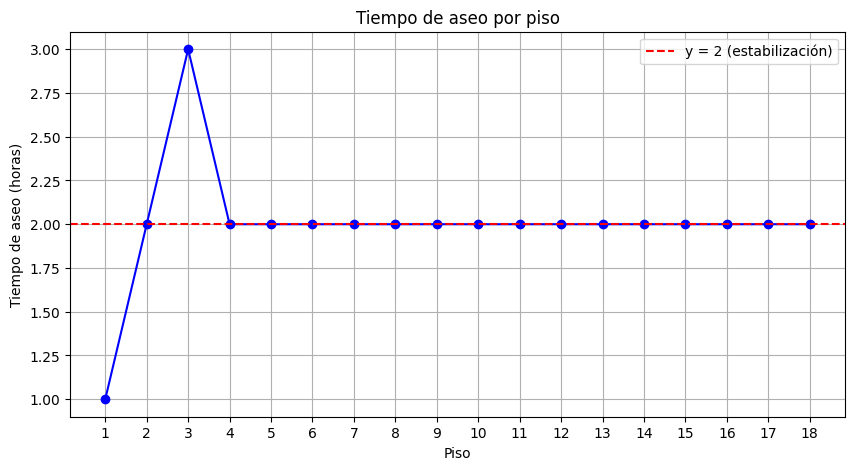

In [39]:
import matplotlib.pyplot as plt

pisos = df['Piso']
tiempos = df['Tiempo (h)']

plt.figure(figsize=(10,5))
plt.plot(pisos, tiempos, marker='o', linestyle='-', color='b')
plt.axhline(y=2, color='r', linestyle='--', label='y = 2 (estabilización)')
plt.xlabel('Piso')
plt.ylabel('Tiempo de aseo (horas)')
plt.title('Tiempo de aseo por piso')
plt.xticks(range(1,19))
plt.grid(True)
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\piso_vs_tiempo.png")
plt.show()


## **5. Problemas similares resueltos**

**Problema 1:**  
Para los pisos 1,2,3: 10, 20, 30 min. Del 4 en adelante: promedio de anteriores. Hallar tiempo piso 10.  
**Solución:**  
$t4 = (10+20+30)/3 = 20;$  
$t5 = (10+20+30+20)/4 = 80/4 = 20;$ se estabiliza en 20.  
$t10 = 20 min.$



**Problema 2:**  
Piso 1: 5 min, piso 2: 7 min, piso 3: 9 min. Del 4 en adelante: promedio anteriores. Hallar piso 8.  
**Solución:**  
t4 = (5+7+9)/3 = 21/3 = 7;  
t5 = (5+7+9+7)/4 = 28/4 = 7; estabilizado.  
t8 = 7 min.

---



**Problema 3:**  
Piso 1: 2 h, piso 2: 4 h, piso 3: 6 h. Del 4 en adelante: promedio anteriores. Hallar piso 12.  
**Solución:**  
t4 = (2+4+6)/3 = 12/3 = 4;  
t5 = (2+4+6+4)/4 = 16/4 = 4; estabilizado.  
t12 = 4 h.

---



**Problema 4:**  
Piso 1: 1 h, piso 2: 1 h, piso 3: 4 h. Del 4 en adelante: promedio anteriores. Hallar piso 9.  
**Solución:**  
t4 = (1+1+4)/3 = 6/3 = 2;  
t5 = (1+1+4+2)/4 = 8/4 = 2;  
t6 = (1+1+4+2+2)/5 = 10/5 = 2; estabilizado.  
t9 = 2 h.

---



**Problema 5:**  
Piso 1: 3 h, piso 2: 5 h, piso 3: 7 h. Del 4 en adelante: promedio anteriores. Hallar piso 20.  
**Solución:**  
t4 = (3+5+7)/3 = 15/3 = 5;  
t5 = (3+5+7+5)/4 = 20/4 = 5; estabilizado.  
t20 = 5 h.

# Pregunta 2 del Tema 6: Compensaciones aditivas y multiplicativas. 

<img src = pregunta_2.jpeg width = 100>

### Transcripción y Edición del Problema

**Enunciado:**
Un tanque de reserva de agua utiliza una bomba neumática para surtirse de un río cercano. Todos los días la bomba sube el nivel del agua **2 m**; por la noche (de las 18 a las 24 horas), el agua se filtra de regreso al río y el nivel baja **50 cm**. Si el tanque inicialmente estaba vacío, el nivel máximo alcanzado por el tanque al final del quinto día de llenado es:

(a) $10\text{ m}$
(b) $8.50\text{ m}$
(c) $8.00\text{ m}$
(d) $7.50\text{ m}$

---



### Análisis Didáctico y Resolución

Para resolver este problema, debemos diferenciar entre el **progreso neto diario** (lo que queda al final de un ciclo de 24 horas) y el **nivel máximo alcanzado** durante el día (antes de que ocurra la filtración nocturna).

#### 1. Datos iniciales
* Aumento diario (bombeo): $A = 2\text{ m}$
* Descenso nocturno (filtración): $D = 50\text{ cm} = 0.5\text{ m}$
* Nivel inicial: $L_0 = 0\text{ m}$



#### 2. Modelo Matemático
El nivel al **final de la jornada de bombeo** del día $n$ se calcula sumando el bombeo al nivel residual del día anterior. El nivel al **final de la noche** es el resultado de restar la filtración.

Sea $M_n$ el nivel máximo al cabo del día $n$ y $R_n$ el nivel residual (final) al cabo del día $n$:

$$M_n = R_{n-1} + 2$$
$$R_n = M_n - 0.5$$



#### 3. Cálculo paso a paso
* **Al término del Día 1:**
    * Máximo: $0 + 2 = 2.0\text{ m}$
    * Residual: $2 - 0.5 = 1.5\text{ m}$
* **Al término del Día 2:**
    * Máximo: $1.5 + 2 = 3.5\text{ m}$
    * Residual: $3.5 - 0.5 = 3.0\text{ m}$
* **Al término del Día 3:**
    * Máximo: $3.0 + 2 = 5.0\text{ m}$
    * Residual: $5.0 - 0.5 = 4.5\text{ m}$
* **Al término del Día 4:**
    * Máximo: $4.5 + 2 = 6.5\text{ m}$
    * Residual: $6.5 - 0.5 = 6.0\text{ m}$
* **Al término del Día 5:**
    * **Máximo: $6.0 + 2 = 8.0\text{ m}$**
    * Residual: $8.0 - 0.5 = 7.5\text{ m}$

**Respuesta Correcta:** Al final del quinto día de llenado (considerando el punto más alto de $8 m$ y luego la filtración de 0.5 m), el nivel final será de **7.5 m**. La opción correcta es la **(d)**.

---



### Representación de Datos con Pandas y Matplotlib

A continuación, presento la tabla de valores y la gráfica del comportamiento del tanque.


 Día  Nivel Máximo (m)  Nivel Final/Noche (m)
   0               0.5                    0.0
   1               2.0                    1.5
   2               3.5                    3.0
   3               5.0                    4.5
   4               6.5                    6.0
   5               8.0                    7.5
   6               9.5                    9.0


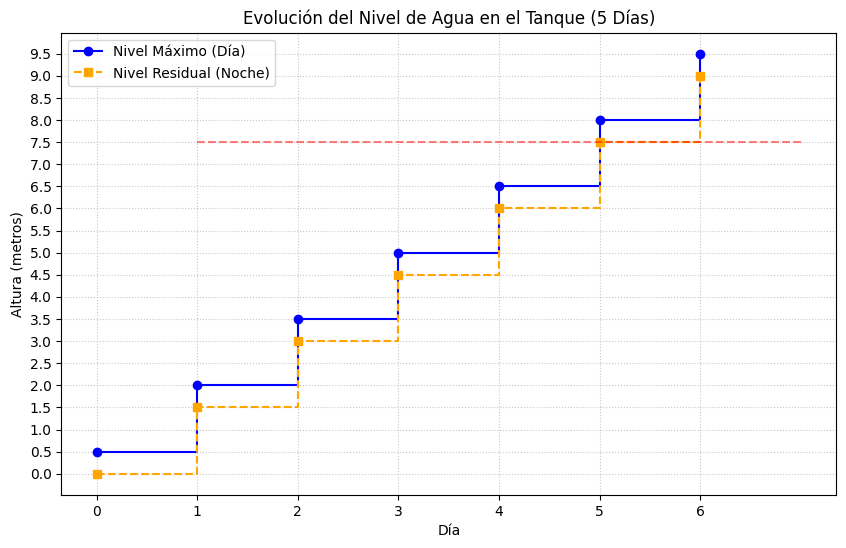

In [21]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

# Creación de los datos
dias = [0, 1, 2, 3, 4, 5, 6]  # Días del 1 al 6
maximos = [0.5, 2.0, 3.5, 5.0, 6.5, 8.0, 9.5]  # Niveles máximos alcanzados cada día
residuales = [0.0, 1.5, 3.0, 4.5, 6.0, 7.5, 9.0]  # Niveles residuales al final de cada día

df = pd.DataFrame({
    'Día': dias,
    'Nivel Máximo (m)': maximos,
    'Nivel Final/Noche (m)': residuales
})

# Mostrar tabla
print(df.to_string(index=False))

# Gráfica con Matplotlib
plt.figure(figsize=(10, 6))
plt.step(dias, maximos, where='post', label='Nivel Máximo (Día)', marker='o', color='blue')
plt.step(dias, residuales, where='post', label='Nivel Residual (Noche)', marker='s', color='orange', \
    linestyle='--')

plt.title('Evolución del Nivel de Agua en el Tanque (5 Días)')
plt.xlabel('Día')
plt.ylabel('Altura (metros)')
plt.xticks(dias)
plt.yticks(np.arange(0, 10, 0.5))
plt.grid(True, linestyle=':', alpha=0.7)
plt.hlines(y=7.5, xmin=1, xmax=7, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\evolucion_nivel_agua.png")
plt.show()


### Interactividad con Plotly (Resumen Visual)

Si estuviéramos en un entorno interactivo, usaríamos **Plotly** para visualizar el crecimiento dinámico:



In [22]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df['Día'], 
    y=df['Nivel Máximo (m)'], 
    name='Nivel Máximo', 
    mode='lines+markers'
))

fig.add_trace(go.Scatter(
    x=df['Día'], 
    y=df['Nivel Final/Noche (m)'], 
    name='Nivel Final', 
    mode='lines+markers'
))

fig.update_layout(
    title='Llenado del Tanque: Máximos vs Residuales',
    xaxis_title='Día',
    yaxis_title='Metros (m)',
    template='plotly_white',
    
    # 🔹 Configuración del eje Y
    yaxis=dict(
        tickmode='linear',  # escala lineal
        tick0=0,            # inicio en 0
        dtick=0.5,            # incremento de 1 en 1
        range=[0, max(df['Nivel Máximo (m)'].max(), df['Nivel Final/Noche (m)'].max()) + 1]
    )
)

fig.show()

fig.write_image(r"C:\Users\marco\Downloads\llenado_del_tanque.jpeg")


### Conclusión
El problema es un ejercicio clásico de **progresión aritmética**. El error común es multiplicar el avance neto ($1.5\text{ m}$) por 5, lo cual daría $7.5\text{ m}$. Sin embargo, la pregunta pide el **nivel máximo al final del quinto día**, lo que implica calcular el nivel después de bombear pero antes de que el agua se filtre por la noche del día 5.

# Preguntas 6 y 7. Tema 6 Compensaciones aditivas y multiplicativas  



<img src = 'preguntas_6_y_7.jpeg' width = 100>

¡Qué buen desafío lógico! Estos problemas de porcentajes y proporciones son excelentes para practicar el pensamiento estructurado. Vamos a transcribir, editar y resolver estas dos preguntas paso a paso.

---

## Transcripción y Edición del Problema

**Contexto General:**
La totalidad de asistentes a un encuentro deportivo están repartidos así (cada asistente es hincha de un único equipo):

I. El $50\%$ son hinchas de los **Leones**.
II. El $50\%$ del resto son hinchas de los **Tigres**.
III. Los hinchas de los **Caimanes** son el doble de los de las **Panteras**.
IV. Los hinchas de las **Águilas** son el mismo número que el de los **Caimanes**.
V. Los hinchas de las **Panteras** son $1000$.

---

### Pregunta 6.6
**El número total de asistentes al encuentro fue:**
(a) $20000$
(b) $22000$
(c) $25000$
(d) $28000$

---



### Pregunta 6.7
**El porcentaje del total de asistentes que son hinchas de las Águilas es:**
(a) $8\%$
(b) $10\%$
(c) $12\%$
(d) $16\%$

---



## Resolución Didáctica

Para resolver este tipo de problemas, lo ideal es trabajar de **abajo hacia arriba**, partiendo del dato numérico concreto.

### 1. Análisis de los grupos (Caimanes, Panteras y Águilas)
Sabemos por el punto **V** que:
$$Panteras = 1000$$

Por el punto **III**, los Caimanes son el doble:
$$Caimanes = 2 \times 1000 = 2000$$

Por el punto **IV**, las Águilas igualan a los Caimanes:
$$Aguilas = 2000$$

Sumemos estos tres grupos para ver cuánto representan del "resto":
$$Subtotal = 1000 + 2000 + 2000 = 5000$$

### 2. Determinando el "Resto" (Tigres y los demás)
El punto **II** dice que el $50\%$ del resto son Tigres. Esto implica que el otro $50\%$ del resto debe ser la suma de Caimanes, Panteras y Águilas.

Si el $50\%$ del resto es $5000$, entonces:
$$Resto = 5000 \times 2 = 10000$$
De aquí deducimos que **Tigres** = $5000$.

### 3. Calculando el Total (Leones)
El punto **I** indica que los Leones son el $50\%$ del total. Esto significa que el "Resto" que acabamos de calcular ($10000$) representa el otro $50\%$.

Por lo tanto, el total de asistentes ($T$) es:
$$T = 10000 \times 2 = 20000$$

**Respuesta 6.6:** La opción correcta es la **(a) 20000**.

### 4. Porcentaje de las Águilas
Para hallar el porcentaje de las Águilas respecto al total de $20000$:
$$P = \frac{Aguilas}{Total} \times 100\%$$
$$P = \frac{2000}{20000} \times 100\% = 0.1 \times 100\% = 10\%$$

**Respuesta 6.7:** La opción correcta es la **(b) 10%**.

---



## Representación de Datos

A continuación, preparamos la estructura de datos con **Pandas** y generamos las visualizaciones solicitadas para entender la distribución.


  Equipo  Asistentes  Porcentaje
  Leones       10000        50.0
  Tigres        5000        25.0
Caimanes        2000        10.0
 Águilas        2000        10.0
Panteras        1000         5.0


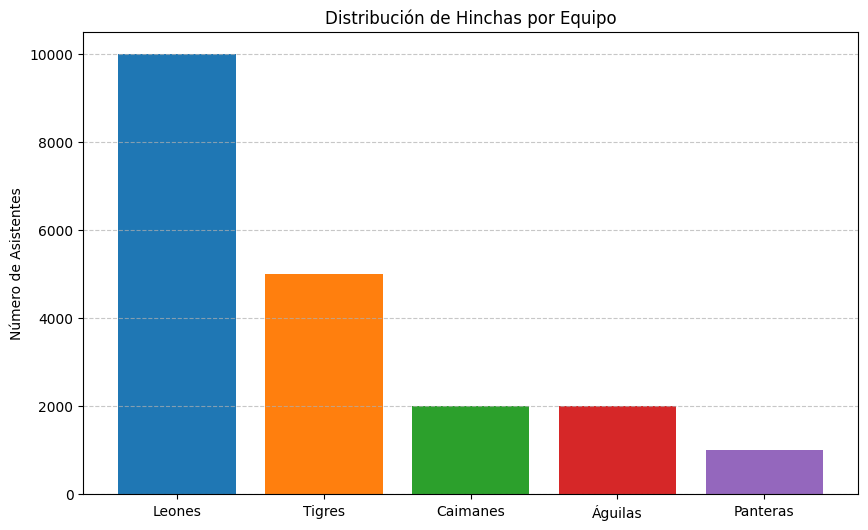

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# Definición de datos
data = {
    'Equipo': ['Leones', 'Tigres', 'Caimanes', 'Águilas', 'Panteras'],
    'Asistentes': [10000, 5000, 2000, 2000, 1000]
}

df = pd.DataFrame(data)
df['Porcentaje'] = (df['Asistentes'] / df['Asistentes'].sum()) * 100

# Tabla resumen
print(df.to_string(index=False))

# Gráfico de Barras con Matplotlib
plt.figure(figsize=(10, 6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
plt.bar(df['Equipo'], df['Asistentes'], color=colors)
plt.title('Distribución de Hinchas por Equipo')
plt.ylabel('Número de Asistentes')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()



### Visualización con Plotly

Para una comparativa más clara de las proporciones:


In [25]:
import plotly.express as px

fig = px.pie(df, values='Asistentes', names='Equipo', 
             title='Participación Porcentual por Equipo',
             hole=0.3,
             color_discrete_sequence=px.colors.qualitative.Pastel)
fig.update_traces(textinfo='percent+label')
fig.show()


> **Resumen de resultados:**
> * **Total de asistentes:** $20000$ personas.
> * **Hinchas de Águilas:** $2000$ personas, lo que equivale exactamente al $10\%$ de la audiencia total.

# Preguntas 8 y 9: 

<img src = preguntas_8_y_9.jpeg width = 100>

¡Este es un excelente problema de optimización geométrica! Vamos a desglosarlo con cuidado, ya que las dimensiones de la escalera están limitadas tanto por la altura como por el ancho disponible.

---

## Transcripción y Edición del Problema

**Contexto General:**
La figura representa una escalera formada por escalones iguales.

* La altura total disponible es de $3\text{ m}$ ($300\text{ cm}$).
* El ancho total disponible (base) es de $6\text{ m}$ ($600\text{ cm}$).
* Si $\overline{xy}$ (ancho de cada escalón) es paralelo al piso y su medida mínima es $25\text{ cm}$.
* Si $\overline{yz}$ (altura de cada escalón) es perpendicular al piso y su medida mínima es $15\text{ cm}$.

---

### Pregunta 6.8
**El número máximo de escalones que puede tener la escalera es:**
(a) $20$
(b) $24$
(c) $25$
(d) $22$

---

### Pregunta 6.9
**Si se usa el número máximo de escalones para formar la escalera, entonces el ancho de cada escalón ($\overline{xy}$), en cm, es:**
(a) $27$
(b) $30$
(c) $32$
(d) $25$

---

## Resolución Didáctica

Para que la escalera tenga el **máximo número de escalones**, cada escalón debe ser lo más pequeño posible, respetando las medidas mínimas dadas.

### 1. Análisis de la restricción por altura (Eje Vertical)
La altura total es $H = 300\text{ cm}$ y la altura mínima de cada escalón es $h_{min} = 15\text{ cm}$.
El número máximo de escalones permitidos por la altura ($N_h$) es:

$$N_h = \frac{H}{h_{min}}$$
$$N_h = \frac{300}{15} = 20\text{ escalones}$$

### 2. Análisis de la restricción por ancho (Eje Horizontal)
El ancho total es $B = 600\text{ cm}$ y el ancho mínimo de cada escalón es $b_{min} = 25\text{ cm}$.
El número máximo de escalones permitidos por el ancho ($N_b$) es:

$$N_b = \frac{B}{b_{min}}$$
$$N_b = \frac{600}{25} = 24\text{ escalones}$$

### 3. Conclusión de la Pregunta 6.8
Un escalón necesita tanto altura como ancho. Por lo tanto, el número de escalones está limitado por el valor más pequeño de los dos cálculos anteriores para asegurar que la escalera quepa en el espacio.

$$N_{max} = \min(N_h, N_b)$$
$$N_{max} = \min(20, 24) = 20$$

**Respuesta 6.8:** La opción correcta es la **(a) 20**.

---

### 4. Resolución de la Pregunta 6.9
Ahora que sabemos que el número máximo de escalones es $n = 20$, debemos calcular el ancho real de cada escalón ($\overline{xy}$) usando el espacio total de la base ($600\text{ cm}$).

$$Ancho\_escalón = \frac{Ancho\_total}{Número\_de\_escalones}$$
$$Ancho\_escalón = \frac{600\text{ cm}}{20}$$
$$Ancho\_escalón = 30\text{ cm}$$

**Respuesta 6.9:** La opción correcta es la **(b) 30**.


---

## Representación de Datos y Visualización

Utilizaremos **Pandas** para comparar las restricciones y **Matplotlib** para visualizar el perfil de la escalera optimizada.

```python
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tabla de Restricciones
datos = {
    'Dimensión': ['Altura (Vertical)', 'Ancho (Horizontal)'],
    'Total Disponible (cm)': [300, 600],
    'Mínimo por Escalón (cm)': [15, 25],
    'Capacidad Máxima (Escalones)': [20, 24]
}
df = pd.DataFrame(datos)
print(df.to_string(index=False))

# 2. Visualización de la Escalera Optimizada (20 escalones)
n = 20
h_step = 300 / n  # 15 cm
w_step = 600 / n  # 30 cm

x_coords = [0]
y_coords = [0]

for i in range(n):
    # Movimiento horizontal (ancho)
    x_coords.append(x_coords[-1] + w_step)
    y_coords.append(y_coords[-1])
    # Movimiento vertical (altura)
    x_coords.append(x_coords[-1])
    y_coords.append(y_coords[-1] + h_step)

plt.figure(figsize=(12, 5))
plt.plot(x_coords, y_coords, color='brown', linewidth=2, label='Perfil de la Escalera')
plt.fill_between(x_coords, y_coords, color='peru', alpha=0.3)
plt.title(f'Visualización de la Escalera Optimizada ({n} escalones)')
plt.xlabel('Ancho Total (cm)')
plt.ylabel('Altura Total (cm)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()
```

### Interactividad con Plotly

Podemos observar la relación entre el número de escalones y el ancho resultante mediante un gráfico de dispersión:

```python


import plotly.express as px

# Datos para diferentes escenarios de número de escalones (de 10 a 24)
escenarios = pd.DataFrame({
    'Escalones': range(10, 25),
    'Ancho_cm': [600/i for i in range(10, 25)],
    'Altura_cm': [300/i for i in range(10, 25)]
})

fig = px.line(escenarios, x='Escalones', y='Ancho_cm', 
              title='Relación: Número de Escalones vs Ancho de Escalón',
              markers=True, labels={'Ancho_cm': 'Ancho (cm)'})
fig.add_hline(y=25, line_dash="dash", line_color="red", annotation_text="Mínimo permitido (25cm)")
fig.show()


> **Nota didáctica:** Aunque el espacio horizontal permitiría hasta 24 escalones, el espacio vertical "manda" en este caso, limitándonos a 20 porque no podemos hacer escalones de menos de $15\text{ cm}$ de alto para cubrir los $3\text{ metros}$. Al tener solo 20 escalones, el ancho de cada uno se estira de los $25\text{ cm}$ mínimos a los $30\text{ cm}$ resultantes.

# Pregunta 10 

<img src = 'pregunta_10.jpeg' width = 100>

Este es un problema de **razonamiento lógico y equivalencias**, comúnmente resuelto mediante la regla de la cadena o un sistema de proporciones. Vamos a desglosarlo.

---

## Transcripción y Edición del Problema

**Enunciado:**
6.10. En un zoológico se ha observado que:
* $17$ osos comen tanto como $170$ monos.
* $100,000$ ratones comen tanto como $50$ monos.
* $4$ elefantes comen tanto como $10$ osos.

**Pregunta:**
El número de ratones que se requiere para acabar la comida de $12$ elefantes es:

(a) $600,000$
(b) $500,000$
(c) $450,000$
(d) $400,000$

---

## Resolución Didáctica

Para resolver este problema, estableceremos una cadena de equivalencias para convertir **Elefantes** en **Ratones**.

### 1. Establecer las equivalencias básicas
Primero, simplificamos las relaciones dadas:

1.  **Osos a Monos:**
    $$17 \text{ osos} = 170 \text{ monos} \implies 1 \text{ oso} = 10 \text{ monos}$$

2.  **Ratones a Monos:**
    $$100,000 \text{ ratones} = 50 \text{ monos} \implies 2,000 \text{ ratones} = 1 \text{ mono}$$

3.  **Elefantes a Osos:**
    $$4 \text{ elefantes} = 10 \text{ osos} \implies 1 \text{ elefante} = 2.5 \text{ osos}$$

### 2. Conversión en cadena
Queremos saber cuántos ratones equivalen a $12$ elefantes. Hagamos la conversión paso a paso:

* **Paso 1: De Elefantes a Osos**
    Si $1 \text{ elefante} = 2.5 \text{ osos}$, entonces:
    $$12 \text{ elefantes} \times 2.5 = 30 \text{ osos}$$

* **Paso 2: De Osos a Monos**
    Si $1 \text{ oso} = 10 \text{ monos}$, entonces:
    $$30 \text{ osos} \times 10 = 300 \text{ monos}$$

* **Paso 3: De Monos a Ratones**
    Si $1 \text{ mono} = 2,000 \text{ ratones}$, entonces:
    $$300 \text{ monos} \times 2,000 = 600,000 \text{ ratones}$$

**Respuesta Correcta:** Se requieren **600,000** ratones. La opción correcta es la **(a)**.

---

## Representación de Datos


### Tabla de Equivalencias Unitarias (Pandas)

Utilizaremos **Pandas** para visualizar cuánto consume cada animal en términos de la unidad base (monos).

```python
import pandas as pd

# Definimos las equivalencias respecto a 1 mono
equivalencias = {
    'Animal': ['Mono', 'Oso', 'Elefante', 'Ratón'],
    'Equivalencia en Monos': [1, 10, 25, 0.0005],
    'Consumo para 12 Elefantes (Unidades)': [300, 30, 12, 600000]
}

df = pd.DataFrame(equivalencias)
print(df.to_string(index=False))
```

### Visualización con Matplotlib

Para entender la escala masiva de los ratones frente a los otros animales, usamos una gráfica de barras (escala logarítmica para mejor visualización):

```python
import matplotlib.pyplot as plt

animales = ['Elefantes', 'Osos', 'Monos', 'Ratones']
cantidades = [12, 30, 300, 600000]

plt.figure(figsize=(10, 6))
plt.bar(animales, cantidades, color=['gray', 'brown', 'orange', 'blue'])
plt.yscale('log') # Escala logarítmica por la diferencia de magnitudes
plt.title('Equivalencia de Consumo para 12 Elefantes')
plt.ylabel('Cantidad de Animales (Escala Logarítmica)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(cantidades):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')

plt.show()
```

### Visualización Interactiva con Plotly

```python
import plotly.graph_objects as go

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = ["12 Elefantes", "30 Osos", "300 Monos", "600,000 Ratones"],
      color = "blue"
    ),
    link = dict(
      source = [0, 1, 2], 
      target = [1, 2, 3],
      value = [12, 12, 12] # Flujo constante de equivalencia
  ))])

fig.update_layout(title_text="Diagrama de Flujo de Equivalencia Alimenticia", font_size=12)
fig.show()
```

> **Conclusión Didáctica:** La clave del ejercicio es encontrar una unidad común. Al convertir todo a "monos" o "osos", la relación final se vuelve una simple multiplicación. Es un recordatorio de que en matemáticas, para comparar peras con manzanas (o elefantes con ratones), necesitamos un **factor de conversión**.

# Pregunta 11  

<img src = 'pregunta_11.jpeg' width = 100>

Este es un problema clásico de **estática y equilibrio de momentos (torques)**. Para que una barra se mantenga en equilibrio horizontal, la suma de los momentos respecto al punto de apoyo debe ser cero.

---

## Transcripción y Edición del Problema

**Enunciado:**
6.11. La figura muestra una barra homogénea colgada del techo horizontalmente desde su punto medio $M$. En los puntos $O$ y $P$ se colgaron las bolsas 1 y 2, respectivamente, con monedas idénticas, pero en número diferente. La bolsa 1 contiene $40$ monedas y la bolsa 2 contiene $20$ monedas.

Si alguien decide quitar $10$ monedas de la bolsa 2 y colocarlas en la bolsa 1, para que la barra continúe horizontal, es necesario que:

(a) La distancia entre $O$ y $M$ sea $5$ veces la distancia entre $M$ y $P$.
(b) La distancia entre $M$ y $P$ sea $5$ veces la distancia entre $O$ y $M$.
(c) La distancia entre $O$ y $M$ sea un tercio de la distancia entre $M$ y $P$.
(d) La distancia entre $M$ y $P$ sea el doble de la distancia entre $O$ y $M$.

---

## Resolución Didáctica

Para resolverlo, utilizaremos el principio de la palanca o **equilibrio de momentos**:
$$\sum \tau = 0 \implies F_1 \cdot d_1 = F_2 \cdot d_2$$

Donde $F$ es el peso (proporcional al número de monedas) y $d$ es la distancia al punto de apoyo $M$.

### 1. Estado inicial de las bolsas
* Bolsa 1 ($O$): $40$ monedas.
* Bolsa 2 ($P$): $20$ monedas.

### 2. Cambio en la configuración
Se quitan $10$ monedas de la bolsa 2 y se ponen en la bolsa 1:
* **Nueva Bolsa 1 ($O$):** $40 + 10 = 50$ monedas ($F_1 = 50$).
* **Nueva Bolsa 2 ($P$):** $20 - 10 = 10$ monedas ($F_2 = 10$).

### 3. Aplicación de la condición de equilibrio
Para que la barra siga horizontal:
$$F_1 \cdot \overline{OM} = F_2 \cdot \overline{MP}$$
Sustituyendo los valores:
$$50 \cdot \overline{OM} = 10 \cdot \overline{MP}$$

Despejamos la relación de distancias:
$$\frac{50}{10} = \frac{\overline{MP}}{\overline{OM}}$$
$$5 = \frac{\overline{MP}}{\overline{OM}} \implies \overline{MP} = 5 \cdot \overline{OM}$$

**Respuesta Correcta:** La distancia entre $M$ y $P$ debe ser $5$ veces la distancia entre $O$ y $M$. La opción correcta es la **(b)**.

---


## Representación de Datos y Visualización

Utilizaremos **Pandas** para comparar el antes y el después, y **Matplotlib** para representar la palanca en equilibrio.

### Comparativa de Pesos (Pandas)

```python
import pandas as pd
import matplotlib.pyplot as plt

# Datos de las bolsas
df = pd.DataFrame({
    'Estado': ['Inicial', 'Final'],
    'Bolsa 1 (en O)': [40, 50],
    'Bolsa 2 (en P)': [20, 10]
})

print(df.to_string(index=False))

# Visualización de la Palanca en equilibrio Final
dist_OM = 1  # Unidad arbitraria
dist_MP = 5  # Basado en el cálculo anterior

plt.figure(figsize=(10, 4))
# Dibujar la barra
plt.axhline(0, color='black', linewidth=3)
# Punto de apoyo M
plt.plot(0, 0, '^', markersize=15, color='red', label='Apoyo M')

# Bolsas (representadas por puntos con tamaño proporcional al peso)
plt.scatter(-dist_OM, 0, s=500, color='blue', label='Bolsa 1 (50 mon.)')
plt.scatter(dist_MP, 0, s=100, color='green', label='Bolsa 2 (10 mon.)')

# Etiquetas de distancias
plt.annotate(f'Dist: {dist_OM}', xy=(-dist_OM/2, 0.1), ha='center')
plt.annotate(f'Dist: {dist_MP}', xy=(dist_MP/2, 0.1), ha='center')

plt.title('Esquema de Equilibrio Final: MP = 5 * OM')
plt.xlim(-2, 6)
plt.ylim(-1, 1)
plt.axis('off')
plt.legend()
plt.show()
```

### Interactividad con Plotly

Podemos ver cómo varía la relación de distancias según el número de monedas:

```python
import plotly.graph_objects as go

monedas_bolsa1 = 50
monedas_bolsa2 = 10
relacion = monedas_bolsa1 / monedas_bolsa2

fig = go.Figure(go.Indicator(
    mode = "gauge+number",
    value = relacion,
    title = {'text': "Relación de Distancia (MP / OM)"},
    gauge = {
        'axis': {'range': [0, 10]},
        'steps': [{'range': [0, 5], 'color': "lightgray"}],
        'threshold': {
            'line': {'color': "red", 'width': 4},
            'thickness': 0.75,
            'value': 5
        }
    }
))

fig.show()
```

> **Nota Didáctica:** El principio de equilibrio de momentos nos enseña que **a menor peso, mayor distancia** se requiere para equilibrar la balanza. Como la bolsa 2 terminó con 5 veces menos peso que la bolsa 1 ($10$ vs $50$), su brazo de palanca debe ser 5 veces mayor para compensar.

# Pregunta 12  



<img src = 'pregunta_12.jpeg' width = 100>

Este es un problema fascinante que combina **lógica combinatoria** y **estática (equilibrio de momentos)**. Para que un móvil de este tipo esté en equilibrio, cada barra horizontal debe estar balanceada respecto a su punto de suspensión.

---

## Transcripción y Edición del Problema

**Enunciado:**
6.12. En el móvil de la figura se colocan cinco pesas de $1$, $2$, $3$, $4$ y $5\text{ kg}$. Si se quiere que el móvil esté en equilibrio, entonces de las afirmaciones siguientes, sobre la pesa que puede ir en la posición de la mitad, la única verdadera es:

(a) Solamente la pesa de $1\text{ kg}$.
(b) Solamente la pesa de $2\text{ kg}$.
(c) La pesa de $2\text{ kg}$ o la de $4\text{ kg}$.
(d) La pesa de $1\text{ kg}$ o la de $3\text{ kg}$.

---

## Resolución Didáctica


Para resolver este problema, debemos analizar la estructura del móvil. Observamos que hay:
1.  Una **barra superior** que sostiene todo el sistema.
2.  Dos **barras inferiores** simétricas (izquierda y derecha).
3.  Una **posición central** (mitad) que cuelga directamente del eje principal.

### 1. Análisis de las barras inferiores
Cada barra inferior tiene dos pesas en sus extremos. Para que estas barras estén en equilibrio (asumiendo que los brazos son iguales), las pesas en sus extremos deben ser iguales o, en este caso, la suma de las pesas de un lado debe equilibrar el sistema global.

Sin embargo, el diagrama muestra que las cuatro pesas externas están agrupadas en dos parejas que cuelgan de una barra principal. Llamemos $P_{centro}$ a la pesa de la mitad y $\{P_1, P_2, P_3, P_4\}$ a las pesas restantes.

### 2. La condición de simetría
El móvil es simétrico. La pesa central no afecta el equilibrio lateral (izquierda vs. derecha) porque cuelga del punto de apoyo principal. El equilibrio depende de que la carga total del lado izquierdo sea igual a la carga total del lado derecho:

$$P_{izq1} + P_{izq2} = P_{der1} + P_{der2}$$

Donde la suma de las cuatro pesas externas debe ser un número par (para poder dividirse en dos grupos iguales).

### 3. Evaluando la Pesa Central ($P_{centro}$)
La suma total de todas las pesas es:
$$S = 1 + 2 + 3 + 4 + 5 = 15\text{ kg}$$

Si quitamos la pesa central, la suma de las cuatro pesas restantes ($S_{restante}$) debe ser divisible por 2:
$$S_{restante} = 15 - P_{centro}$$

Probemos con cada pesa:
* Si $P_{centro} = 1 \implies S_{restante} = 15 - 1 = 14$. Es par ($7 + 7$). Parejas posibles: $(2,5)$ y $(3,4)$. **(Posible)**
* Si $P_{centro} = 2 \implies S_{restante} = 15 - 2 = 13$. Es impar. **(Imposible)**
* Si $P_{centro} = 3 \implies S_{restante} = 15 - 3 = 12$. Es par ($6 + 6$). Parejas posibles: $(1,5)$ y $(2,4)$. **(Posible)**
* Si $P_{centro} = 4 \implies S_{restante} = 15 - 4 = 11$. Es impar. **(Imposible)**
* Si $P_{centro} = 5 \implies S_{restante} = 15 - 5 = 10$. Es par ($5 + 5$). Pero solo quedan $\{1,2,3,4\}$, y ninguna combinación suma $5$ y $5$ sin repetir números. **(Imposible)**

**Respuesta Correcta:** La pesa central solo puede ser la de **1 kg o la de 3 kg**. La opción correcta es la **(d)**.

---

## Representación de Datos y Simulación

A continuación, presentamos una tabla de las combinaciones posibles y una visualización del equilibrio.

### Tabla de Combinaciones (Pandas)

```python
import pandas as pd

# Análisis de paridad para la pesa central
pesas = [1, 2, 3, 4, 5]
resultados = []

for p in pesas:
    restantes = [x for x in pesas if x != p]
    suma_r = sum(restantes)
    posible = "Sí" if suma_r % 2 == 0 else "No"
    # Verificación adicional de si se pueden formar las parejas
    if posible == "Sí":
        # Chequeo manual de sub-sumas
        can_split = any(sum([restantes[0], restantes[i]]) == suma_r/2 for i in range(1,4))
        if not can_split: posible = "No (Suma par, pero sin parejas)"
    
    resultados.append([p, suma_r, posible])

df = pd.DataFrame(resultados, columns=['Pesa Central', 'Suma Restantes', '¿Equilibrio Posible?'])
print(df.to_string(index=False))
```

### Visualización del Equilibrio (Matplotlib)

Representamos el escenario donde la pesa de **3 kg** está en el centro.

```python
import matplotlib.pyplot as plt

# Escenario: Pesa central = 3. Parejas: (1,5) y (2,4)
fig, ax = plt.subplots(figsize=(8, 6))

# Barra principal
ax.plot([-2, 2], [2, 2], 'black', lw=4)
ax.plot([0, 0], [2, 3], 'black', lw=2) # Cable al techo

# Pesa central (3kg)
ax.plot([0, 0], [2, 1], 'black', lw=2)
ax.add_patch(plt.Circle((0, 0.8), 0.2, color='red'))
ax.text(0, 0.75, '3', ha='center', color='white', weight='bold')

# Brazos secundarios
ax.plot([-2, -2], [2, 1], 'black', lw=2)
ax.plot([2, 2], [2, 1], 'black', lw=2)
ax.plot([-2.5, -1.5], [1, 1], 'black', lw=3) # Barra izq
ax.plot([1.5, 2.5], [1, 1], 'black', lw=3)   # Barra der

# Pesas laterales (Pareja 1,5 y 2,4)
# Izquierda
ax.add_patch(plt.Circle((-2.5, 0.5), 0.15, color='blue')) # 1kg
ax.text(-2.5, 0.45, '1', ha='center', color='white')
ax.add_patch(plt.Circle((-1.5, 0.5), 0.15, color='blue')) # 5kg
ax.text(-1.5, 0.45, '5', ha='center', color='white')

# Derecha
ax.add_patch(plt.Circle((1.5, 0.5), 0.15, color='green')) # 2kg
ax.text(1.5, 0.45, '2', ha='center', color='white')
ax.add_patch(plt.Circle((2.5, 0.5), 0.15, color='green')) # 4kg
ax.text(2.5, 0.45, '4', ha='center', color='white')

ax.set_xlim(-3, 3)
ax.set_ylim(0, 3.5)
ax.set_title("Configuración de Equilibrio con Pesa de 3kg en el Centro")
ax.axis('off')
plt.show()
```

### Gráfico de Pesos con Plotly

```python
import plotly.express as px

df_plot = pd.DataFrame({
    'Lado': ['Izquierda', 'Izquierda', 'Centro', 'Derecha', 'Derecha'],
    'Peso (kg)': [1, 5, 3, 2, 4]
})

fig = px.bar(df_plot, x='Lado', y='Peso (kg)', color='Lado',
             title='Distribución de Masas para Equilibrio (Opción Pesa Central = 3)')
fig.show()
```

> **Conclusión:** Este ejercicio demuestra que el equilibrio no solo depende de la física, sino de la **teoría de números**. Al identificar que la suma de las pesas externas debe ser un número par y capaz de ser particionado en dos sumas iguales, descartamos rápidamente las opciones incorrectas.

Terminado la preparación de la clase 6 desde el cuaderno de Trabajo de Razonamiento Lógico. 




# Clase 6

# Compensaciones aditivas y multiplicativas

Duración: **3 horas**

Este tema es **muy típico en pruebas de razonamiento cuantitativo** como las del examen de admisión de la Universidad de Antioquia porque evalúa **equilibrio de cantidades, ajustes y conservación de relaciones**.

---



# Objetivos de la clase

Al finalizar la clase el estudiante podrá:

* resolver problemas de **compensación aditiva**
* resolver problemas de **compensación multiplicativa**
* interpretar **equilibrios en gráficos**
* verificar soluciones con **Python**
* resolver preguntas **en menos de 2 minutos**

---



# Concepto 1

# Compensación aditiva

Una **compensación aditiva** ocurre cuando un aumento en una cantidad debe compensarse con una **disminución equivalente** en otra para mantener un equilibrio.

Ejemplo:

Si un promedio debe mantenerse constante, entonces

$$
\text{suma total} = \text{constante}
$$

---



# Concepto 2

# Compensación multiplicativa

Ocurre cuando el **producto entre variables debe permanecer constante**.

Ejemplo típico: trabajo, velocidad-tiempo, precio-cantidad.

$$
x \times y = k
$$

---



# PARTE I

# 13 problemas tipo prueba diagnóstica

---

# Problema 1

El promedio de **5 números** es $20$.

Si uno de los números aumenta en **5 unidades**, ¿qué debe ocurrir con otro número para que el promedio no cambie?

A) disminuir 2
B) disminuir 3
C) disminuir 5
D) disminuir 10

---



## Estrategia

Suma total original

$$
5 \times 20
$$

---

$$
100
$$

Si un número aumenta 5, la suma sería

$$
105
$$

Para mantener el promedio:

otro número debe disminuir **5**.

---

* **Respuesta: C**

---



## Python

```python
suma=5*20
suma_nueva=suma+5
suma_nueva-5
```

---



# Problema 2

Un estudiante tiene promedio $4.0$ en **4 notas**.

¿Cuánto debe obtener en la quinta nota para mantener el promedio?

A) 3
B) 4
C) 5
D) 6

---



## Estrategia

Suma actual

$$
4\times4=16
$$

Para mantener promedio:

$$
5\times4=20
$$

Nota necesaria

$$
20-16
$$

---



$$
4
$$

---

* **Respuesta B**

---



# Problema 3

Un trabajador realiza un trabajo en **6 días**.

Si ahora trabaja **el doble de rápido**, ¿cuánto tarda?

A) 2
B) 3
C) 4
D) 6

---

## Compensación multiplicativa

$$
\text{velocidad} \times \text{tiempo}
$$

---

Velocidad ×2

Tiempo ÷2

---

$$
3
$$

---

✅ **Respuesta B**

---

# Problema 4

Una máquina produce **200 piezas en 4 horas**.

¿Cuántas producirá en **6 horas**?

A) 250
B) 275
C) 300
D) 350

---

## Estrategia

Producción por hora

$$
200/4
$$

---

$$
50
$$

---

$$
50\times6
$$

---

$$
300
$$

---



* **Respuesta C**

---



# Problema 5 (con gráfico)

Producción de una fábrica.

```python


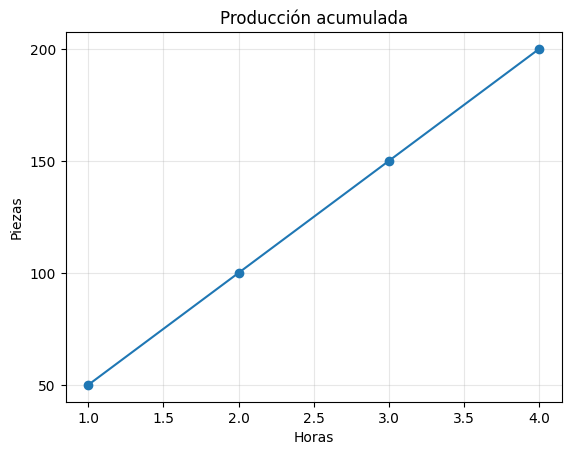

In [43]:
import numpy as np 
import matplotlib.pyplot as plt

horas=[1,2,3,4]
produccion=[50,100,150,200]

plt.plot(horas,produccion,marker="o")
plt.title("Producción acumulada")
plt.xlabel("Horas")
plt.ylabel("Piezas")
plt.grid(alpha = 0.3)
plt.yticks(np.arange(50, 250, 50))
plt.savefig(r"C:\Users\marco\Downloads\produccion_acumulada.png")
plt.show()



## Pregunta

Si la relación se mantiene, ¿cuántas piezas se producen en **5 horas**?

---

$$
50\times5
$$

---

$$
250
$$

---



# Problema 6

Si el precio de un producto aumenta **10%**, ¿cuánto debe disminuir la cantidad vendida para mantener el ingreso constante?

Ingreso

$$
P \times Q
$$

---

Aproximadamente

$$
10%
$$

---

# Problema 7

Promedio de 4 números es $10$.

Si uno aumenta en **4**, otro debe disminuir:

---

$$
4
$$

---

# Problema 8

Un auto recorre **120 km en 2 horas**.

A la misma velocidad en **3 horas** recorrerá

---

$$
180
$$

---

# Problema 9

Si el número de trabajadores se **duplica**, el tiempo necesario se:

---

divide entre

$$
2
$$

---

# Problema 10

Un tanque se llena en **10 horas**.

Con dos llaves iguales:

---

$$
5
$$

---

# Problema 11

Promedio de tres números es $15$.

Suma total

---

$$
45
$$

---

# Problema 12

Si el precio se duplica y la cantidad se reduce a la mitad, el ingreso:

---

permanece

---

**igual**

---

# Problema 13

Velocidad se triplica.

Tiempo necesario

---

$$
1/3
$$

---



# PARTE II

# 13 problemas similares (tipo examen)

---

# Problema 14

Promedio de **6 números** es $12$.

Suma total.

---

$$
72
$$

---



# Problema 15

Si un número aumenta **8**, otro debe disminuir:

---

$$
8
$$

---

# Problema 16

Velocidad ×2 → tiempo

---

$$
/2
$$

---

# Problema 17

Precio ×3 → cantidad

---

$$
/3
$$

---

# Problema 18

Promedio de **5 números = 30**

Suma

---

$$
150
$$

---

# Problema 19

Trabajo de 8 días con doble eficiencia.

---

$$
4
$$

---

# Problema 20

Producción por hora **60**

En **7 horas**

---

$$
420
$$

---



# Problema 21

Promedio de **4 números = 18**

Suma

---

$$
72
$$

---

# Problema 22

Precio ×1.2

Cantidad para ingreso constante

---

$$
\approx /1.2
$$

---

# Problema 23

Si trabajadores ×3 → tiempo

---

$$
/3
$$

---

# Problema 24

Promedio constante → compensación

---

**aditiva**

---

# Problema 25

Trabajo duplicado con misma velocidad → tiempo

---

×2

---



# Problema 26

Velocidad ×4 → tiempo

---

$$
/4
$$

---



# Visualización con matplotlib

# Compensación multiplicativa



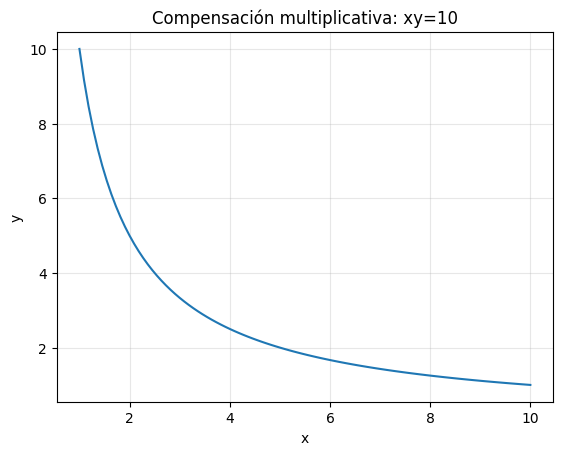

In [44]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(1,10,100)
y=10/x

plt.plot(x,y)
plt.title("Compensación multiplicativa: xy=10")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.5)
plt.grid(alpha = 0.3)
plt.savefig(r"C:\Users\marco\Downloads\compensacion_multiplicativa.png")
plt.show()



# Visualización de compensación aditiva



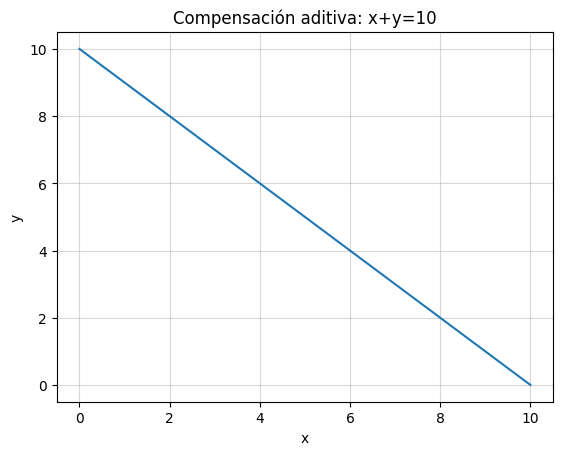

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x=np.linspace(0,10,100)
y=10-x

plt.plot(x,y)
plt.title("Compensación aditiva: x+y=10")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.5)
plt.savefig(r"C:\Users\marco\Downloads\compensacion_aditiva.png")
plt.show()



# Estrategia para el examen

Cuando aparezcan estos problemas:

1. identificar si el **equilibrio es suma o producto**

* promedio → **compensación aditiva**
* trabajo / velocidad / precio-cantidad → **multiplicativa**

2. usar relaciones rápidas:

$$
x+y=k
$$

o

$$
xy=k
$$

---
